# Linear Regression Model

Existing studies on waste bin fill-level prediction commonly adopt linear or regression-based approaches as an initial benchmark to estimate short-term bin fill behaviour and support collection planning. These studies subsequently apply more advanced models, such as Gaussian Process Regression, which have been shown to achieve better predictive performance (Brouwer et al., 2023; Ferrer & Alba, 2019; Krishna et al., 2025).

In line with these studies, Linear Regression is applied in this project to predict short-term bin fill levels using features derived from the sensor dataset, such as the current fill percentage and time since the last collection. As the ultrasonic sensor readings are recorded at irregular time intervals rather than fixed daily intervals, the next observed fill level is treated as a next-day fill estimate for collection planning purposes.



‌



In [153]:
from datasets import load_dataset
import pandas as pd

dataset = load_dataset("SA61team5/AD-tableA")

df = pd.DataFrame(dataset["train"])

print(df.shape)


tableA.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/27601 [00:00<?, ? examples/s]

(27601, 10)


In [154]:
df.head()

,Index,ContainerID,Timestamp,Fill_percentage,Rec,Cidx,Month,Is_weekend,Days_since_last_REC,Next_day_fill_percentage
0,0,1000,2021-01-16 13:28:00,52.5,1,0.0,1,1,0,52.5
1,1,1000,2021-01-17 12:34:00,52.5,0,0.0,1,1,0,52.5
2,2,1000,2021-01-18 12:41:00,52.5,0,0.0,1,0,1,52.5
3,3,1000,2021-01-19 12:48:00,52.5,0,0.0,1,0,2,52.5
4,4,1000,2021-01-20 18:27:00,52.5,0,0.0,1,0,4,52.5


## Time-based train-test split

Instead of randomly splitting the data, earlier records will be used for training while later records are reserved for testing.

In [155]:
df["Timestamp"] = pd.to_datetime(df["Timestamp"])
split_date = df["Timestamp"].quantile(0.75)

train_df = df[df["Timestamp"] <= split_date]
test_df  = df[df["Timestamp"] > split_date]

features = ["Fill_percentage", "Month", "Is_weekend", "Days_since_last_REC"]

X_train = train_df[features]
y_train = train_df["Next_day_fill_percentage"]

X_test  = test_df[features]
y_test  = test_df["Next_day_fill_percentage"]

## Model Training

In [156]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

## Model Prediction

In [157]:
y_pred = model.predict(X_test)

## Model Evaluation
Mean Absolute Error (MAE) is used to measure the average absolute difference between the predicted and actual bin fill levels, indicating how far predictions typically deviate from actual fill levels. (Ferrer & Alba, 2019; Krishna et al., 2025).

Root Mean Squared Error (RMSE) is used to assess the impact of large errors on planning decisions (Krishna et al., 2025).

MAE at high fill levels (≥80%) is used to evaluate model performance when bins are close to being full. This is important because prediction accuracy near collection thresholds has a greater impact on operational decision-making than average fill behaviour.

In [158]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")

high_fill = y_test >= 80

mae_high = mean_absolute_error(
    y_test[high_fill],
    y_pred[high_fill]
)

print(f"MAE @ High Fill (≥80%) : {mae_high:.2f}")

MAE  : 12.43
RMSE : 19.06
MAE @ High Fill (≥80%) : 31.67


## Intepreting Evaluation Results
1) MAE = 12.43

    On average, the model’s predicted bin fill level differs from the actual fill level by about 12.4 percentage points.

2) RMSE = 19.06

    RMSE indicates that while most predictions deviate from the actual fill level by about 12.4 percentage points, there are cases where larger errors occur, with deviations of up to around 19 percentage points. These larger errors may occur during irregular fill behaviour, such as sudden increases in usage or or variations related to collection schedules.

3) MAE @ High Fill (≥80%) = 31.67

    When bins are close to being full, the average prediction error increases to about 30 percentage points. This suggests that the Linear Regression model struggles more in high-risk situations near collection thresholds, where fill behaviour may become less linear or more variable. This limitation highlights why Linear Regression is suitable as a baseline model but may not be sufficient on its own for accurate overflow risk prediction.

## Partial Dependence Plot 
Partial Dependence Plots were used to analyse how each feature influences the predicted next fill level while holding other features constant. 

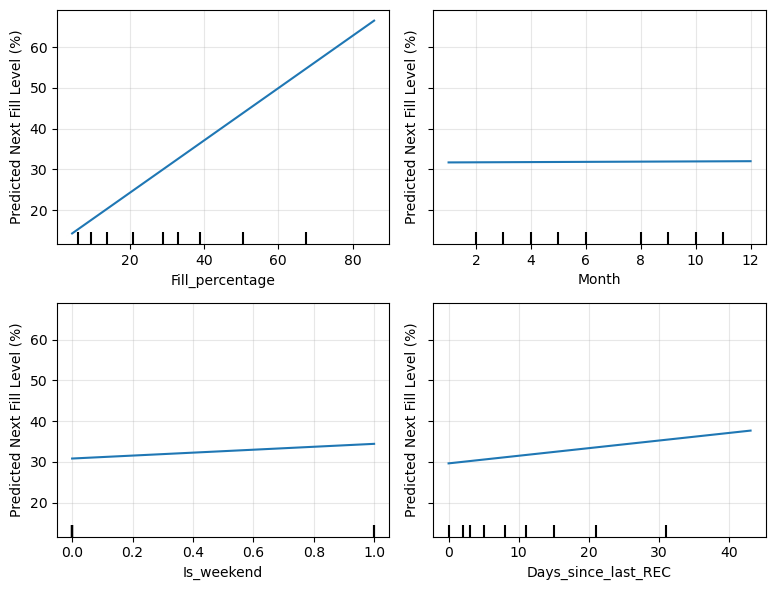

In [159]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(8, 6)
)

disp = PartialDependenceDisplay.from_estimator(
    model,
    X_train,
    features=features,
    ax=ax,
    grid_resolution=60
)

for i, axi in enumerate(ax.flat):
    axi.set_xlabel(features[i], fontsize=10)
    axi.set_ylabel("Predicted Next Fill Level (%)", fontsize=10)
    axi.grid(alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 1])
plt.show()

The graph for fill_percentage shows a strong positive linear relationship with the predicted next-day fill level. As the current fill level increases, the predicted next-day fill level rises proportionally.

The graph for month shows a nearly flat trend, indicating that seasonal effects, including holiday periods or technology sales cycles, have limited influence on next-day fill level predictions.

The graph for is_weekend shows a slight positive effect on predicted fill levels during weekends compared to weekdays. However, the magnitude of this effect is relatively small.

The graph for days_since_last_REC shows a weak positive relationship with the predicted next-day fill level. After capping extreme values, this feature reflects a modest increase in predicted fill as time since last collection grows, though its influence remains secondary compared to the current fill level. 

## Conclusion
Overall, both the evaluation results and the partial dependence analysis show that the Linear Regression model relies heavily on the current bin fill level, with time-related and collection features having only a minor effect. While the model captures straightforward linear relationships, its higher errors at high fill levels and limited response to collection-related feature suggest that it struggles to represent irregular fill behaviour. This highlights the need for more flexible non-linear models, such as Gaussian Process Regression, which are better able to capture complex accumulation patterns and provide predictions with associated uncertainty (Brouwer et al., 2023; Ferrer & Alba, 2019).

## References

Brouwer, Y., Ana Paula Barbosa-Póvoa, António Pais Antunes, & Rodrigues, T. (2023). Comparison of different waste bin monitoring approaches: An exploratory study. Waste Management & Research (Online), 41(10), 1570–1583. https://doi.org/10.1177/0734242x231160691
‌

Ferrer, J., & Alba, E. (2019). BIN-CT: Urban waste collection based on predicting the container fill level. Biosystems, 186, 103962. https://doi.org/10.1016/j.biosystems.2019.04.006

Krishna, S. R., Bhukya Kranthikumar, Swathy Vodithala, Waseem, Md. Sharfuddin., & Kireet Muppavaram. (2025). A Machine Learning Framework For Predictive Waste Management Optimization In Smart Cities. International Journal of Environmental Sciences, 11(12s), 328–334. https://doi.org/10.64252/zp92vp11

In [ ]:
# Deploy model

import joblib

joblib.dump(model, "../model.pkl")

['../model.pkl']

In [162]:
# Test prediction

X_test_manual = pd.DataFrame([{
    "Fill_percentage": 40,
    "Month": 1,
    "Is_weekend": 0,
    "Days_since_last_REC": 1
}])

pred = model.predict(X_test_manual)
print("Prediction:", pred)

Prediction: [33.88144622]
